# 확률변수와 상관분석
### Yahoo Finance API를 활용한 실시간 주가 데이터를 통해 잘 아는 기업(예: 애플, 테슬라 등)의 실제 주가를 가져와 수익률(확률변수)의 분포를 보고 상관관계를 분석
– Yfinance : Python을 사용하여 야후 파이낸스에서 주식, ETF, 암호화폐 등 다양한 금융 데이
터를 무료로 수집할 수 있는 라이브러리


 데이터 분석 포인트

– 리스크와 수익률에 기반하여 어떻게 투자할까?

– 양의 상관관계를 가진 종목/기업은?

– 음의 상관관계를 가진 종목/기업은?

– 상관관계가 없는 종목/기업은?



In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
ticker=['AAPL','TSLA','GOOGL','^GSPC','GC=F','BTC-USD','CL=F','DX-Y.NYB']
data= yf.download(ticker, start='2023-01-01',auto_adjust=
True)['Close']
print(data.head())


[*********************100%***********************]  8 of 8 completed

Ticker            AAPL       BTC-USD       CL=F    DX-Y.NYB         GC=F  \
Date                                                                       
2023-01-01         NaN  16625.080078        NaN         NaN          NaN   
2023-01-02         NaN  16688.470703        NaN         NaN          NaN   
2023-01-03  122.982735  16679.857422  76.930000  104.519997  1839.699951   
2023-01-04  124.251190  16863.238281  72.839996  104.250000  1852.800049   
2023-01-05  122.933548  16836.736328  73.669998  105.040001  1834.800049   

Ticker          GOOGL        TSLA        ^GSPC  
Date                                            
2023-01-01        NaN         NaN          NaN  
2023-01-02        NaN         NaN          NaN  
2023-01-03  88.336700  108.099998  3824.139893  
2023-01-04  87.305847  113.639999  3852.969971  
2023-01-05  85.442360  110.339996  3808.100098  


In [8]:
returns=data.pct_change().dropna()
print(returns.head())

Ticker          AAPL   BTC-USD      CL=F  DX-Y.NYB      GC=F     GOOGL  \
Date                                                                     
2023-01-04  0.010314  0.010994 -0.053165 -0.002583  0.007121 -0.011670   
2023-01-05 -0.010605 -0.001572  0.011395  0.007578 -0.009715 -0.021344   
2023-01-06  0.036794  0.006844  0.001357 -0.011043  0.016023  0.013225   
2023-01-07  0.000000  0.000183  0.000000  0.000000  0.000000  0.000000   
2023-01-08  0.000000  0.008025  0.000000  0.000000  0.000000  0.000000   

Ticker          TSLA     ^GSPC  
Date                            
2023-01-04  0.051249  0.007539  
2023-01-05 -0.029039 -0.011646  
2023-01-06  0.024651  0.022841  
2023-01-07  0.000000  0.000000  
2023-01-08  0.000000  0.000000  


/tmp/ipykernel_9692/1718948474.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns=data.pct_change().dropna()


In [9]:
summary=returns.agg(['mean','std'])
print(summary)


Ticker      AAPL   BTC-USD      CL=F  DX-Y.NYB      GC=F     GOOGL      TSLA  \
mean    0.000746  0.001297  0.000126 -0.000018  0.000678  0.001178  0.001435   
std     0.013370  0.024697  0.020126  0.003438  0.010397  0.015854  0.030123   

Ticker     ^GSPC  
mean    0.000544  
std     0.007799  


Text(0.5, 1.0, 'Stack correlation matrix')

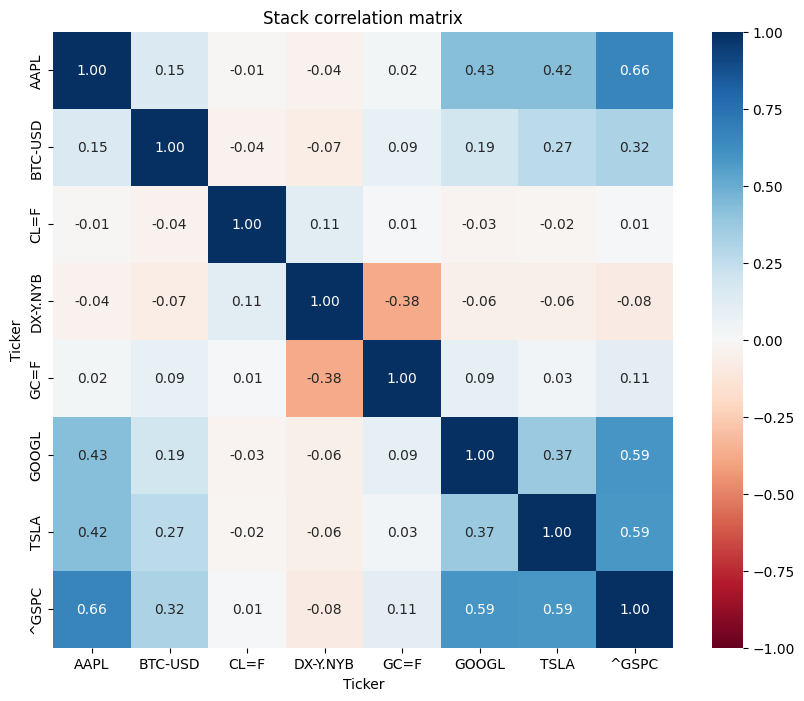

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(),annot=True,cmap='RdBu',vmin=-1,vmax=1,fmt=
'.2f')
plt.title('Stack correlation matrix')

ticker을 이용해 금융데이터를 분석한 결과 첫번째로
### 수익률과 리스크를 표준편차 결과로 본 결과
- .테슬라가 평균은 가장 높지만 표준편차도 매우 높기때무에 높은수익률과 하이리스크를 의미함을 알
수 있다.
-  반대로 ^GSPC는 낮은 표준편차로 안정적인 수치를 나타내지만 수익률 역시 낮은 수준임을
알 수 있다.
- 수익률과 안정성을 따졌을때 평균값과 표준편차 모두 조사한 기업들중 중범위에
들어오는 구글과 금이 안정성도 어느정도 보장되고 수익률도 나쁘지않다고 분석할 수 있다.

결론 :따라서
투자자의 성격과 계획에 따라 **단기성으로 많은 돈을 벌고 싶으면 하이리스크 하이리턴인 테슬라**가,
**자본이 많고 오래동안 투자할 의향이 있다면 smp500을 투자**할것 같다.

두번째로
###히트맵을 통해 양의 상관관계를 분석하면
1. AAPL이 ^GSPC랑 가장높은 0.68로 높은
상관관계를 보였으며 이를이어 AAPL은 GOOGL,TESLA와 0.45, 0.43으로 미국의 대기업들과 높은
상관관계를 보였다
2.  ^GSPC와 GOOGL, TSLA 모두 0.6,0.59로 높은 상관관계를 보였다.

결론: 애플 구글 테슬라 모두
AI,미래성장,혁신을 바탕으로 같은 키워드를 핵심으로 여기는 기업들이기도 하며 모두 기술 기반
성장주이기 때문에 금리의 영향을 받기 떄문 **굵은 텍스트**에 이러한 높은 상관관계가 생겼다고 분석할 수 있다.


세번째로
###음의 상관관계를 살펴보면
-  GC=F와 DX-Y.NYB두개가 -0.37로 가장 낮은 상관관계를
보임을 알 수 있다.

결론: 이는 금과 달러로 금의 가치는 달러로 결정되기 때문달러의 가치가 높아지면 금의
가격도올라수요가 낮아져 금의 가격이 낮아지고 달러의 가치가 낮아지면 금의 가격이 저렴해져
수요가 높아져 금의 가격이 올라감을 음의 상관계수로 설명해줄 수 있다.
- 이외에도 금과
애플,비트코인과 달러 비트코인과 wit크루드 오일 원유산물역시 -0.04,
-0.06정도로 적지만 음의
상관관계를 갖고 있음을 알 수 있다

네번째로
### 0.00으로 상관관계가 아예 없는 관계
-  GC=f와 TSL로 금과 테슬라의 주가는 서로에게
영향을 별로 미치지 못한다는것과 AAPL과 GC=F역시 0은 아니지만 0.01로 정말 미미한 영향을
미친다는 사실을 알 수 있다.